In [1]:
using Random
using PyPlot
using Statistics
using OrdinaryDiffEq
using LinearAlgebra

using Profile
using ProfileView

include("SuperradiantLasing/SuperradiantLasing.jl")
using .SuperradiantLasing

for n in names(SuperradiantLasing, all=true)
    @eval import .SuperradiantLasing: $(n)
end



In [2]:
using LinearAlgebra
using DifferentialEquations

# ----------------------------
# Parameters
# ----------------------------
Base.@kwdef struct BadCavityParams
    N::Int
    g::Float64          # single-atom cavity coupling (paper's Ω)
    kappa::Float64      # cavity linewidth (paper's κ)
    gamma::Float64      # spontaneous decay rate (paper's γ)
    w::Float64          # repump rate
    gamma_phi::Float64  # pure dephasing rate, replacing 1/T2
    Delta::Float64 = 0.0  # cavity-atom detuning Δ = ωc - ωa
end

# ----------------------------
# Mean-field / cumulant EOM
#
# State vector:
# u = [z, Re(p), Im(p), c, n]
#
# z = <σ^z>
# p = <a† σ^->
# c = <σ1^+ σ2^->
# n = <a† a>
#
# Uses the paper's Eq. (2)-(5), with 1/T2 -> gamma_phi,
# and neglects the third-order cumulant in Eq. (3),
# exactly as stated there.
# ----------------------------
function badcavity_rhs!(du, u, pars::BadCavityParams, t)
    z, px, py, c, n = u
    p = px + 1im * py

    N  = pars.N
    g  = pars.g
    κ  = pars.kappa
    γ  = pars.gamma
    w  = pars.w
    γϕ = pars.gamma_phi
    Δ  = pars.Delta

    d0 = (w - γ) / (w + γ)

    # Eq. (2)
    dz = -(w + γ) * (z - d0) + 1im * g * (p - conj(p))

    # Eq. (3), third-order cumulant dropped
    #dp = -((w + γ)/2 + γϕ + κ/2 - 1im * Δ) * p +
    #     1im * g/2 * (n * z + z/2 + (N - 1) * c)
    dp = -((w + γ)/2 + γϕ + κ/2 - 1im * Δ) * p +
     1im * g/2 * (n * z + (z + 1)/2 + (N - 1) * c)

    # Eq. (4)
    dc = -(w + γ + 2γϕ) * c + (g * z / (2im)) * (p - conj(p))

    # Eq. (5)
    dn = -κ * n + (N * g / (2im)) * (p - conj(p))

    du[1] = real(dz)
    du[2] = real(dp)
    du[3] = imag(dp)
    du[4] = real(dc)   # c stays real in the resonant case
    du[5] = real(dn)
    return nothing
end

# ----------------------------
# Integrate to steady state
# ----------------------------
function badcavity_steady_state(pars::BadCavityParams;
        u0 = [0.0, 0.0, 0.0, 0.0, 0.0],
        tmax = 10_000.0,
        reltol = 1e-10,
        abstol = 1e-12)

    prob = ODEProblem(badcavity_rhs!, u0, (0.0, tmax), pars)
    sol = solve(prob, Rodas5P(); reltol=reltol, abstol=abstol)

    u = sol.u[end]
    z, px, py, c, n = u
    p = px + 1im * py

    return (
        z = z,
        p = p,
        c = c,
        n = n,
        sol = sol,
    )
end

# ----------------------------
# Regression matrix for the spectrum
#
# q(t) = [ G(t), H(t) ]^T
# G(t) = <a†(t) a(0)>
# H(t) = <σ^+(t) a(0)>
#
# Following the paper's Eq. (9), but with pure dephasing γϕ
# instead of 1/T2, so the transverse decay is:
# Γperp = (w + γ)/2 + γϕ
#
# On resonance, the spectrum is Lorentzian in the paper's closure.
# Here we evaluate it directly from the resolvent, which is more robust.
# ----------------------------
function regression_matrix(pars::BadCavityParams, z_ss)
    N  = pars.N
    g  = pars.g
    κ  = pars.kappa
    γ  = pars.gamma
    w  = pars.w
    γϕ = pars.gamma_phi
    Δ  = pars.Delta

    Γperp = (w + γ)/2 + γϕ

    # q̇ = A q
    A = ComplexF64[
        -κ/2                    1im * N * g / 2
        -1im * g * z_ss / 2    -(Γperp + 1im * Δ)
    ]
    return A
end

# ----------------------------
# Spectrum from the Laplace/resolvent formula
#
# S(ω) = 2 Re ∫_0^∞ dt e^{i ω t} <a†(t) a(0)>
#
# For q̇ = A q and q(0) = q0:
# ∫_0^∞ dt e^{iω t} q(t) = -(A + iω I)^(-1) q0
# ----------------------------
function badcavity_spectrum(ωgrid, pars::BadCavityParams, ss)
    z_ss = ss.z
    n_ss = ss.n
    p_ss = ss.p

    A = regression_matrix(pars, z_ss)

    # Initial conditions from the steady state
    # G(0) = <a† a> = n_ss
    # H(0) = <σ^+ a> = conj(<a† σ^->) = conj(p_ss)
    q0 = ComplexF64[n_ss, conj(p_ss)]

    S = similar(ωgrid, Float64)
    I2 = Matrix{ComplexF64}(I, 2, 2)

    for (j, ω) in pairs(ωgrid)
        val = ((1im * ω * I2 - A) \ q0)
        S[j] = 2 * real(val[1])
    end

    return S
end

# ----------------------------
# Convenience wrapper
# ----------------------------
function steady_state_and_spectrum(ωgrid, pars::BadCavityParams;
        u0 = [0.0, 0.0, 0.0, 0.0, 0.0],
        tmax = 10_000.0)

    #@show pars.w / (pars.N * pars.g^2 / pars.kappa)

    ss = badcavity_steady_state(pars; u0=u0, tmax=tmax)
    Sω = badcavity_spectrum(ωgrid, pars, ss)
    return ss, Sω
end


steady_state_and_spectrum (generic function with 1 method)

In [3]:

# ============================================
# Burn-in / quasi-stationary approximation
# ============================================

# Simulate exactly only up to t_mix.
# Returns:
#   contrib      : contribution on τ_grid for τ <= t_mix
#   survived     : whether trajectory is still alive at t_mix
#   amp_mix      : alive amplitude at t_mix, i.e. w_in * readout(state at t_mix)
#   sink_mix     : sink rate at t_mix
#   S_mix, M_mix : state at t_mix (mainly for diagnostics)
function simulate_coherence_sector_to_mix(
    model::CoherenceModel,
    S0::Int,
    M0::Int,
    τ_grid::AbstractVector,
    t_mix::Float64;
    rng::AbstractRNG = Random.default_rng(),
)
    st = CoherenceState(S0, M0, 0.0, false)
    buf = CoherenceEventBuffer()

    contrib = zeros(Float64, length(τ_grid))
    w_in = initial_coherence_weight(S0, M0)

    if !valid_coherence_state(S0, M0, model.Jmax)
        return contrib, false, 0.0, 0.0, S0, M0
    end

    idx = 1
    nτ = length(τ_grid)

    while idx <= nτ
        τ = τ_grid[idx]
        if τ > t_mix
            break
        end

        current_val = st.absorbed ? 0.0 : w_in * coherence_readout(st.S, st.M)

        ok = coherence_step!(rng, st, buf, model)

        if !ok
            @inbounds while idx <= nτ && τ_grid[idx] <= t_mix
                contrib[idx] = current_val
                idx += 1
            end
            return contrib, false, 0.0, 0.0, st.S, st.M
        end

        @inbounds while idx <= nτ && τ_grid[idx] <= min(st.t, t_mix)
            contrib[idx] = current_val
            idx += 1
        end

        if st.absorbed
            @inbounds while idx <= nτ && τ_grid[idx] <= t_mix
                contrib[idx] = 0.0
                idx += 1
            end
            return contrib, false, 0.0, 0.0, st.S, st.M
        end
    end

    # If no event reached t_mix yet, fill remaining early grid points with current value
    if !st.absorbed
        current_val = w_in * coherence_readout(st.S, st.M)
        @inbounds while idx <= nτ && τ_grid[idx] <= t_mix
            contrib[idx] = current_val
            idx += 1
        end

        build_coherence_events!(buf, model, st)
        sink_mix = buf.sink_rate
        amp_mix = current_val
        return contrib, true, amp_mix, sink_mix, st.S, st.M
    else
        return contrib, false, 0.0, 0.0, st.S, st.M
    end
end


# Build tail from a deterministic quasi-stationary exponential
@inline function add_deterministic_qs_tail!(
    Cτ::AbstractVector,
    τ_grid::AbstractVector,
    t_mix::Float64,
    amp_mix::Float64,
    λ_qs::Float64,
)
    if amp_mix == 0.0
        return nothing
    end

    @inbounds for i in eachindex(τ_grid)
        τ = τ_grid[i]
        if τ > t_mix
            Cτ[i] += amp_mix * exp(-λ_qs * (τ - t_mix))
        end
    end
    return nothing
end


# Build tail from one sampled exponential absorption time
@inline function add_sampled_qs_tail!(
    Cτ::AbstractVector,
    τ_grid::AbstractVector,
    t_mix::Float64,
    amp_mix::Float64,
    λ_qs::Float64,
    rng::AbstractRNG,
)
    if amp_mix == 0.0
        return nothing
    end

    if λ_qs <= 0.0
        @inbounds for i in eachindex(τ_grid)
            if τ_grid[i] > t_mix
                Cτ[i] += amp_mix
            end
        end
        return nothing
    end

    T_tail = -log(rand(rng)) / λ_qs
    t_abs = t_mix + T_tail

    @inbounds for i in eachindex(τ_grid)
        τ = τ_grid[i]
        if τ > t_mix && τ <= t_abs
            Cτ[i] += amp_mix
        end
    end

    return nothing
end


# Main approximation from initial samples.
#
# tail_mode = :deterministic  -> amp_mix * exp(-λ_qs (τ-t_mix))
# tail_mode = :sampled        -> amp_mix * 1_{τ < t_mix + Exp(λ_qs)}
#
# estimate_lambda = :mean_sink
#   λ_qs = average sink rate over survivors at t_mix
#
function simulate_coherence_correlator_from_samples_qs(
    S_samples::AbstractVector{Int},
    M_samples::AbstractVector{Int},
    model::CoherenceModel;
    τ_max::Float64,
    t_mix::Float64,
    n_grid::Int = 1000,
    tail_mode::Symbol = :deterministic,
    rng::AbstractRNG = Random.default_rng(),
)
    @assert length(S_samples) == length(M_samples)
    #@assert 0.0 <= t_mix <= τ_max

    τ_grid = collect(range(0.0, τ_max, length = n_grid))
    Cτ = zeros(Float64, n_grid)

    N = length(S_samples)
    survived = falses(N)
    amp_mix = zeros(Float64, N)
    sink_mix = zeros(Float64, N)
    S_mix = zeros(Int, N)
    M_mix = zeros(Int, N)

    # exact burn-in
    for n in eachindex(S_samples)
        contrib_n, survived_n, amp_n, sink_n, S_n, M_n = simulate_coherence_sector_to_mix(
            model,
            S_samples[n],
            M_samples[n],
            τ_grid,
            t_mix;
            rng = rng,
        )

        Cτ .+= contrib_n
        survived[n] = survived_n
        amp_mix[n] = amp_n
        sink_mix[n] = sink_n
        S_mix[n] = S_n
        M_mix[n] = M_n
    end

    n_surv = count(survived)

    λ_qs = n_surv == 0 ? 0.0 : sum(sink_mix[survived]) / n_surv

    # approximate tail
    if tail_mode == :deterministic
        for n in eachindex(S_samples)
            if survived[n]
                add_deterministic_qs_tail!(Cτ, τ_grid, t_mix, amp_mix[n], λ_qs)
            end
        end
    elseif tail_mode == :sampled
        for n in eachindex(S_samples)
            if survived[n]
                add_sampled_qs_tail!(Cτ, τ_grid, t_mix, amp_mix[n], λ_qs, rng)
            end
        end
    else
        error("Unknown tail_mode = $tail_mode. Use :deterministic or :sampled.")
    end

    Cτ ./= N

    stats = (
        λ_qs = λ_qs,
        n_survived = n_surv,
        survival_fraction = n_surv / N,
        mean_amp_mix = n_surv == 0 ? 0.0 : sum(amp_mix[survived]) / n_surv,
        mean_sink_mix = λ_qs,
        S_mix = S_mix,
        M_mix = M_mix,
        amp_mix = amp_mix,
        sink_mix = sink_mix,
        survived = survived,
    )

    return τ_grid, Cτ, stats
end


function simulate_correlator_qs(
    pop_model::PopulationModel;
    N_traj::Int,
    t_ss::Float64,
    τ_max::Float64,
    t_mix::Float64,
    n_grid::Int = 1000,
    S0::Int = pop_model.Jmax,
    M0::Int = pop_model.Jmax,
    tail_mode::Symbol = :deterministic,
    rng::AbstractRNG = Random.default_rng(),
)
    S_samples, M_samples = get_stationary_population_samples(
        pop_model,
        N_traj;
        t_ss = t_ss,
        S0 = S0,
        M0 = M0,
        rng = rng,
    )

    coh_model = CoherenceModel(pop_model)

    τ_grid, Cτ, stats = simulate_coherence_correlator_from_samples_qs(
        S_samples,
        M_samples,
        coh_model;
        τ_max = τ_max,
        t_mix = t_mix,
        n_grid = n_grid,
        tail_mode = tail_mode,
        rng = rng,
    )

    return τ_grid, Cτ, S_samples, M_samples, stats
end


function simulate_correlator_ergodic_qs(
    pop_model::PopulationModel;
    N_traj::Int,
    t_ss::Float64,
    τ_max::Float64,
    t_mix::Float64,
    n_grid::Int = 1000,
    S0::Int = pop_model.Jmax,
    M0::Int = pop_model.Jmax,
    tail_mode::Symbol = :deterministic,
    rng::AbstractRNG = Random.default_rng(),
)
    S_samples, M_samples = get_stationary_population_samples_ergodic(
        pop_model,
        N_traj;
        t_ss = t_ss,
        t_sample = t_ss * 3,
        S0 = S0,
        M0 = M0,
        rng = rng,
    )

    coh_model = CoherenceModel(pop_model)

    τ_grid, Cτ, stats = simulate_coherence_correlator_from_samples_qs(
        S_samples,
        M_samples,
        coh_model;
        τ_max = τ_max,
        t_mix = t_mix,
        n_grid = n_grid,
        tail_mode = tail_mode,
        rng = rng,
    )

    return τ_grid, Cτ, S_samples, M_samples, stats
end

simulate_correlator_ergodic_qs (generic function with 1 method)

In [4]:
# ============================================
# Burn-in / quasi-stationary approximation
# Optimized version:
# - no per-trajectory contrib allocation
# - deterministic tail added only once globally
# - fewer repeated τ <= t_mix checks
# ============================================

# Simulate exactly only up to t_mix, accumulating directly into Cτ.
# Returns:
#   survived     : whether trajectory is still alive at t_mix
#   amp_mix      : alive amplitude at t_mix, i.e. w_in * readout(state at t_mix)
#   sink_mix     : sink rate at t_mix
#   S_mix, M_mix : state at t_mix
function accumulate_coherence_sector_to_mix!(
    Cτ::AbstractVector{Float64},
    model::CoherenceModel,
    S0::Int,
    M0::Int,
    τ_grid::AbstractVector,
    t_mix::Float64,
    i_mix::Int;
    rng::AbstractRNG = Random.default_rng(),
)
    st = CoherenceState(S0, M0, 0.0, false)
    buf = CoherenceEventBuffer()

    w_in = initial_coherence_weight(S0, M0)

    if !valid_coherence_state(S0, M0, model.Jmax)
        return false, 0.0, 0.0, S0, M0
    end

    idx = 1

    while idx <= i_mix
        current_val = st.absorbed ? 0.0 : w_in * coherence_readout(st.S, st.M)

        ok = coherence_step!(rng, st, buf, model)

        if !ok
            @inbounds while idx <= i_mix
                Cτ[idx] += current_val
                idx += 1
            end
            return false, 0.0, 0.0, st.S, st.M
        end

        fill_until_t = min(st.t, t_mix)
        @inbounds while idx <= i_mix && τ_grid[idx] <= fill_until_t
            Cτ[idx] += current_val
            idx += 1
        end

        if st.absorbed
            # remaining entries up to i_mix get zero contribution
            return false, 0.0, 0.0, st.S, st.M
        end
    end

    # If no event reached t_mix yet, fill remaining early points with current value
    if !st.absorbed
        current_val = w_in * coherence_readout(st.S, st.M)
        @inbounds while idx <= i_mix
            Cτ[idx] += current_val
            idx += 1
        end

        build_coherence_events!(buf, model, st)
        sink_mix = buf.sink_rate
        amp_mix = current_val
        return true, amp_mix, sink_mix, st.S, st.M
    else
        return false, 0.0, 0.0, st.S, st.M
    end
end


# Build tail from one sampled exponential absorption time
# Optimized: starts from i_mix+1 rather than scanning the full grid
@inline function add_sampled_qs_tail!(
    Cτ::AbstractVector,
    τ_grid::AbstractVector,
    i_mix::Int,
    t_mix::Float64,
    amp_mix::Float64,
    λ_qs::Float64,
    rng::AbstractRNG,
)
    if amp_mix == 0.0
        return nothing
    end

    if λ_qs <= 0.0
        @inbounds for i in i_mix+1:length(τ_grid)
            Cτ[i] += amp_mix
        end
        return nothing
    end

    T_tail = -log(rand(rng)) / λ_qs
    t_abs = t_mix + T_tail

    @inbounds for i in i_mix+1:length(τ_grid)
        τ = τ_grid[i]
        if τ <= t_abs
            Cτ[i] += amp_mix
        else
            break
        end
    end

    return nothing
end


function simulate_coherence_correlator_from_samples_qs(
    S_samples::AbstractVector{Int},
    M_samples::AbstractVector{Int},
    model::CoherenceModel;
    τ_max::Float64,
    t_mix::Float64,
    n_grid::Int = 1000,
    tail_mode::Symbol = :deterministic,
    rng::AbstractRNG = Random.default_rng(),
)
    @assert length(S_samples) == length(M_samples)
    @assert 0.0 <= t_mix <= τ_max

    τ_grid = collect(range(0.0, τ_max, length = n_grid))
    Cτ = zeros(Float64, n_grid)

    N = length(S_samples)
    survived = falses(N)
    amp_mix = zeros(Float64, N)
    sink_mix = zeros(Float64, N)
    S_mix = zeros(Int, N)
    M_mix = zeros(Int, N)

    i_mix = searchsortedlast(τ_grid, t_mix)

    # exact burn-in accumulated directly into Cτ
    for n in eachindex(S_samples)
        survived_n, amp_n, sink_n, S_n, M_n = accumulate_coherence_sector_to_mix!(
            Cτ,
            model,
            S_samples[n],
            M_samples[n],
            τ_grid,
            t_mix,
            i_mix;
            rng = rng,
        )

        survived[n] = survived_n
        amp_mix[n] = amp_n
        sink_mix[n] = sink_n
        S_mix[n] = S_n
        M_mix[n] = M_n
    end

    n_surv = count(survived)
    λ_qs = n_surv == 0 ? 0.0 : sum(sink_mix[survived]) / n_surv

    # approximate tail
    if tail_mode == :deterministic
        amp_total = sum(amp_mix[survived])
        if amp_total != 0.0
            @inbounds for i in i_mix+1:n_grid
                Cτ[i] += amp_total * exp(-λ_qs * (τ_grid[i] - t_mix))
            end
        end
    elseif tail_mode == :sampled
        for n in eachindex(S_samples)
            if survived[n]
                add_sampled_qs_tail!(Cτ, τ_grid, i_mix, t_mix, amp_mix[n], λ_qs, rng)
            end
        end
    else
        error("Unknown tail_mode = $tail_mode. Use :deterministic or :sampled.")
    end

    Cτ ./= N

    stats = (
        λ_qs = λ_qs,
        n_survived = n_surv,
        survival_fraction = n_surv / N,
        mean_amp_mix = n_surv == 0 ? 0.0 : sum(amp_mix[survived]) / n_surv,
        mean_sink_mix = λ_qs,
        S_mix = S_mix,
        M_mix = M_mix,
        amp_mix = amp_mix,
        sink_mix = sink_mix,
        survived = survived,
    )

    return τ_grid, Cτ, stats
end

simulate_coherence_correlator_from_samples_qs (generic function with 1 method)

In [5]:
using PyPlot

function linewidth_from_regression_matrix(pars, ss)
    A = regression_matrix(pars, ss.z)
    vals = eigvals(A)
    λslow = vals[argmax(real.(vals))]
    Δω = - real(λslow)
    return Δω
end

# --------------------------------
# linewidth scan for PRL Fig. 3(b)
# --------------------------------
function scan_w_linewidth_badcavity(
    ws;
    N::Int = 10^6,
    g::Float64 = 37.0,
    kappa::Float64 = 9.4e5,
    gamma::Float64 = 0.01,
    gamma_phi::Float64 = 1.0,   # use this as 1/T2
    Delta::Float64 = 0.0,
    nω::Int = 12001,
    ωmax_factor::Float64 = 20.0,
    tmax_ss::Float64 = 2.0e4,
    u0 = [0.0, 0.0, 0.0, 0.0, 0.0],
)
    widths = Float64[]
    nss = Float64[]
    zss = Float64[]
    pss = ComplexF64[]

    for w in ws
        #@show w
        pars = BadCavityParams(
            N = N,
            g = g,
            kappa = kappa,
            gamma = gamma,
            w = w,
            gamma_phi = gamma_phi,
            Delta = Delta,
        )

        # choose a frequency window that scales with the expected broadening
        # at large w the linewidth can become O(w), so use max(gamma_phi, w)
        ωmax = ωmax_factor * max(gamma_phi, gamma, w, g^2 * N / kappa / 100)
        ωgrid = range(-ωmax, ωmax, length=nω)

        ss, Sω = steady_state_and_spectrum(ωgrid, pars; u0=u0, tmax=tmax_ss)
        #Δν = spectrum_fwhm(collect(ωgrid), Sω)
        push!(widths, linewidth_from_regression_matrix(pars, ss))

        #push!(widths, Δν)
        push!(nss, ss.n)
        push!(zss, ss.z)
        push!(pss, ss.p)
    end

    return (
        ws = collect(ws),
        widths = widths,
        nss = nss,
        zss = zss,
        pss = pss,
        wmax = N * g^2 / kappa,
        gamma = gamma,
        gamma_phi = gamma_phi,
    )
end

# --------------------------------
# plotting helper for panel (b)
# --------------------------------
function plot_prl_fig3b_like(scan)
    figure(figsize=(5.2, 4.0))

    loglog(scan.ws, scan.widths, label = L"\Delta \nu")

    axvline(scan.gamma, color="k", linestyle="--", linewidth=1)
    axvline(scan.gamma_phi, color="k", linestyle="--", linewidth=1)
    axvline(scan.wmax, color="k", linestyle="--", linewidth=1)

    xlabel(L"w\ [\mathrm{s}^{-1}]")
    ylabel(L"\Delta \nu\ [\mathrm{s}^{-1}]")

    text(scan.gamma * 1.05, maximum(scan.widths) / 5, L"\gamma")
    text(scan.gamma_phi * 1.05, maximum(scan.widths) / 5, L"T_2^{-1}")
    text(scan.wmax * 1.05, maximum(scan.widths) / 5, L"w_{\max}")

    grid(true, which="both", alpha=0.3)
    tight_layout()
end

# --------------------------------
# reasonable defaults for arbitrary N
# reuses:
#   scan_w_linewidth_badcavity
#   plot_prl_fig3b_like
# --------------------------------
function plot_linewidth_cut_for_N(
    N::Int;
    g::Float64 = 37.0,
    kappa::Float64 = 9.4e5,
    gamma::Float64 = 0.01,
    gamma_phi::Float64 = 1.0,   # interpreted as 1/T2 in your code
    Delta::Float64 = 0.0,
    ws = nothing,
    npts::Int = 120,
    nω::Int = 12001,
    ωmax_factor::Float64 = 20.0,
    tmax_ss::Float64 = 2.0e4,
    u0 = [0.0, 0.0, 0.0, 0.0, 0.0],
)
    wmax = N * g^2 / kappa

    if ws === nothing
        scales = [gamma, gamma_phi, wmax]
        positive_scales = [x for x in scales if x > 0]
        wmin = min(minimum(positive_scales) / 10, 1e-3)
        wmax_plot = max(maximum(positive_scales) * 100, 1e2)
        ws = 10.0 .^ range(log10(wmin), log10(wmax_plot), length=npts)
    end

    @show g^2 / kappa

    scan = scan_w_linewidth_badcavity(
        ws;
        N = N,
        g = g,
        kappa = kappa,
        gamma = gamma,
        gamma_phi = gamma_phi,
        Delta = Delta,
        nω = nω,
        ωmax_factor = ωmax_factor,
        tmax_ss = tmax_ss,
        u0 = u0,
    )

    plot_prl_fig3b_like(scan)
    title("N = $(N)")

    return scan
end

plot_linewidth_cut_for_N (generic function with 1 method)

In [6]:
using PyPlot
using Random
using LsqFit

function linewidth_from_correlator_tail(τ_grid, Cτ; fit_frac=(0.0, 1.0))
    a, b = fit_frac
    N = length(τ_grid)
    i1 = max(2, round(Int, a * N))
    i2 = min(N, round(Int, b * N))

    if i2 < i1
        return NaN
    end

    τ = τ_grid[i1:i2]
    y = abs.(Cτ[i1:i2])

    mask = isfinite.(τ) .& isfinite.(y) .& (y .> 0)
    τ = τ[mask]
    y = y[mask]

    if length(τ) < 5
        return NaN
    end

    β = hcat(ones(length(τ)), τ) \ log.(y)
    slope = β[2]

    if !isfinite(slope) || slope >= 0
        return NaN
    end

    Δω = - slope
    return Δω
end

function linewidth_from_correlator_tail2(τ_grid, Cτ; rel_window=(3e-1, 1e-7))
    y = abs.(Cτ)
    y0 = maximum(y)

    if !isfinite(y0) || y0 <= 0
        return NaN
    end

    hi, lo = rel_window
    mask = isfinite.(τ_grid) .& isfinite.(y) .& (y .<= hi*y0) .& (y .>= lo*y0)

    τ = τ_grid[mask]
    yy = y[mask]

    if length(τ) < 2
        return NaN
    end

    β = hcat(ones(length(τ)), τ) \ log.(yy)
    slope = β[2]

    if !isfinite(slope) || slope >= 0
        return NaN
    end

    return -slope
end


# --------------------------------
# MC linewidth scan vs w
# Reuses:
#   PopulationModel
#   simulate_correlator_ergodic_qs
#   spectrum_even_fft
#   spectrum_fwhm
# --------------------------------
function scan_w_linewidth_mc(
    ws;
    N::Int,
    global_decay::Float64,
    local_decay::Float64 = 0.0,
    local_dephasing::Float64 = 0.0,
    N_traj::Int = 2000,
    t_ss = nothing,
    t_mix = nothing,
    τ_max = nothing,
    n_grid::Int = 4000,
    tail_mode = :deterministic,
    seed::Int = 1234,
    verbose::Bool = true,
)
    # sensible defaults in units of the effective collective rate scale
    Γcoll = N * global_decay
    t_ss === nothing && (t_ss = 20 / Γcoll)
    t_mix === nothing && (t_mix = t_ss)
    τ_max === nothing && (τ_max = 200 / global_decay)

    widths = Float64[]
    spectra = Vector{Vector{Float64}}()

    for (j, w) in pairs(ws)
        @show j
        @show τ_max[j]
        flush(stdout)
        verbose && display("[$j/$(length(ws))] w = $w")

        mc_model = PopulationModel(
            N,
            N ÷ 2,
            global_decay,
            0.0,
            local_decay,
            w,
            local_dephasing,
        )

        τ_grid, Cτ_qs_mc, S_samples, M_samples, stats = simulate_correlator_ergodic_qs(
            mc_model;
            N_traj = N_traj,
            t_ss = t_ss,
            τ_max = τ_max[j],
            t_mix = t_mix,
            n_grid = n_grid,
            tail_mode = tail_mode,
            rng = Xoshiro(seed),
        )

        plot(τ_grid, Cτ_qs_mc)


        Δν = linewidth_from_correlator_tail2(τ_grid, Cτ_qs_mc)
        plot(τ_grid, Cτ_qs_mc, label = w)

        push!(widths, Δν)
    end

    return (
        ws = collect(ws),
        widths = widths,
        spectra = spectra,
        global_decay = global_decay,
        N = N,
        local_decay = local_decay,
        local_dephasing = local_dephasing,
        t_ss = t_ss,
        t_mix = t_mix,
        τ_max = τ_max,
        N_traj = N_traj,
    )
end

# --------------------------------
# Plot helper in the same spirit as the PRL-style cut
# --------------------------------
function plot_linewidth_scan_mc(scan; gamma=nothing, gamma_phi=nothing, show_wmax=true)
    figure(figsize=(5.4, 4.0))
    loglog(scan.ws, scan.widths, marker="o", linestyle="-", label="MC")

    if gamma !== nothing && gamma > 0
        axvline(gamma, color="k", linestyle="--", linewidth=1)
    end
    if gamma_phi !== nothing && gamma_phi > 0
        axvline(gamma_phi, color="k", linestyle="--", linewidth=1)
    end
    if show_wmax
        wmax = scan.N * scan.global_decay
        axvline(wmax, color="k", linestyle="--", linewidth=1)
    end

    xlabel(L"w")
    ylabel(L"\Delta \nu")
    grid(true, which="both", alpha=0.3)
    legend()
    tight_layout()
end

plot_linewidth_scan_mc (generic function with 1 method)

g ^ 2 / kappa = 0.0014563829787234042

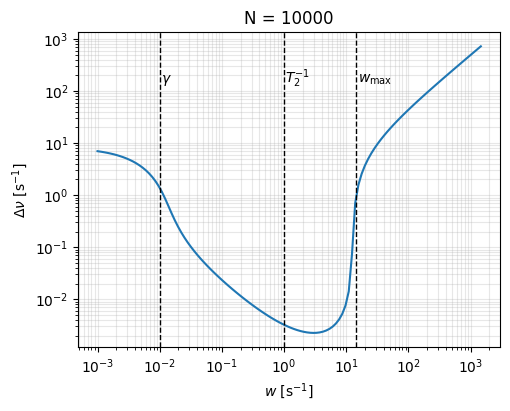

(ws = [0.001, 0.0011266583296444012, 0.0012693589917571108, 0.0014301338813721676, 0.0016112722499546305, 0.0018153533017362601, 0.0020452829186486214, 0.002304335036774881, 0.0025961982634738574, 0.0029250283989511513  …  497.90387650445706, 560.9675498259838, 632.0187626716553, 712.0692034555684, 802.258699356469, 903.8714461596493, 1018.3542937434997, 1147.3373475752553, 1292.6571795577734, 1456.3829787234038], widths = [6.988272081075646, 6.840706309758685, 6.678504481328125, 6.500714373465624, 6.306438583867927, 6.094867014729315, 5.86531441548132, 5.617262759657459, 5.350408003745848, 5.064710618213605  …  242.67159812267695, 274.20290777343865, 309.727929456899, 349.75249901434427, 394.84652072228647, 445.6520820781441, 502.89259639235314, 567.3831033668424, 640.0418743281549, 721.9034873602637], nss = [1.9888994534132364e-7, 2.2628079715278157e-7, 2.5778897625058615e-7, 2.941368161833986e-7, 3.3620516850969007e-7, 3.850782325719082e-7, 4.4210443758089395e-7, 5.089804311646757e-

In [7]:
plot_linewidth_cut_for_N(10^4)

In [8]:
N = 10000
g = 37.0
kappa = 9.4e5
gamma = 0.01
gamma_phi = 1.0
Delta = 0.0

Γ = g^2 / kappa
ws = 10.0 .^ range(-4, 4, length=500) .* (N * Γ)

scan_cum = scan_w_linewidth_badcavity(
    ws;
    N = N,
    g = g,
    kappa = kappa,
    gamma = gamma,
    gamma_phi = gamma_phi,
    Delta = Delta,
    tmax_ss = 2.0e4,
)


ws = 10.0 .^ range(-4, 4, length=50) .* (N * Γ)

scan_mc =  scan_w_linewidth_mc(
    ws;
    N = N,
    global_decay = Γ,
    local_decay = gamma,
    local_dephasing = gamma_phi,
    N_traj = 3000,
    t_ss = 0.05 / Γ,
    t_mix = 0.05 / Γ,
    τ_max = 3.0 ./ scan_cum.widths,
    n_grid = 100,
    tail_mode = :deterministic,
    seed = 1234,
    verbose = false
)

yscale("log")
ylim(bottom = 1e-12)
legend()

j = 1
τ_max[j] = 0.4635229233863616


LoadError: AssertionError: 0.0 <= t_mix <= τ_max

In [ ]:
scan_mc.widths

50-element Vector{Float64}:
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
   ⋮
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN

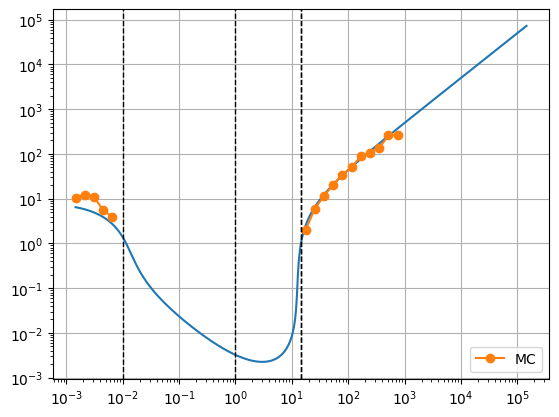

In [ ]:
loglog(scan_cum.ws, scan_cum.widths)
loglog(scan_mc.ws, scan_mc.widths, marker="o", linestyle="-", label="MC")
axvline(scan_cum.gamma, color="k", linestyle="--", linewidth=1)
axvline(scan_cum.gamma_phi, color="k", linestyle="--", linewidth=1)
axvline(scan_mc.N * scan_mc.global_decay, color="k", linestyle="--", linewidth=1)
axvline(scan_cum.wmax, color="k", linestyle="--", linewidth=1)


legend()
grid()